In [1]:
import numpy as np
import pandas as pd

In [2]:
from libcbm.model.model_definition import model
from libcbm.model.model_definition.model import CBMModel
from libcbm.model.model_definition.output_processor import ModelOutputProcessor
from libcbm.model.model_definition.model_variables import ModelVariables

In [3]:
pool_def = [
    "Input",
    "WoodyBiomass",
    "Foliage",
    "SlowDOM",
    "MediumDOM",
    "FastDOM",
    "CO2",
    "Products",
]

In [4]:
flux_indicators = [
    {
        "name": "NPP",
        "process": "GrowthAndMortality",
        "source_pools": ["Input", "Foliage"],
        "sink_pools": [
            "WoodyBiomass",
            "Foliage",
            "FastDOM",
        ],
    },
    {
        "name": "DecayEmissions",
        "process": "Decay",
        "source_pools": [
            "SlowDOM",
            "MediumDOM",
            "FastDOM",
        ],
        "sink_pools": ["CO2"],
    },
    {
        "name": "DisturbanceEmissions",
        "process": "Disturbance",
        "source_pools": [
            "WoodyBiomass",
            "Foliage",
            "SlowDOM",
            "MediumDOM",
            "FastDOM",
        ],
        "sink_pools": ["CO2"],
    },
    {
        "name": "HarvestProduction",
        "process": "Disturbance",
        "source_pools": [
            "WoodyBiomass",
            "Foliage",
            "MediumDOM",
        ],
        "sink_pools": ["Products"],
    },
]

In [5]:
def weibull_cumulative(x, k=2.3, y=1):
    c = np.power(x / y, k)
    return 1 - np.exp(-c)

def create_npp_matrix(cbm_model: CBMModel, age: np.ndarray):
    # creates NPP flows based on an age passed to the cumulative
    # weibull distribution
    npp = weibull_cumulative((age + 1) / 100.0) - weibull_cumulative(
        age / 100.0
    )
    cbm_model.matrix_ops.create_operation(
        name="growth",
        op_process_name="GrowthAndMortality",
        op_data=pd.DataFrame(
            data={
                # since age is 1:1 with simulation areas, this
                # matrix is defined with a unique entry for each
                # simulation area
                "Input.WoodyBiomass": npp,
                "Input.Foliage": npp / 10.0,
            }
        ),
    )

<Axes: >

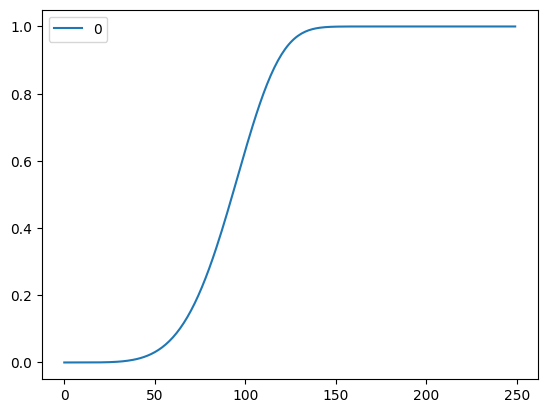

In [6]:
pd.DataFrame([weibull_cumulative(x,5,1) for x in np.arange(0,2.5,0.01)]).plot()

In [7]:
def create_mortality_matrix(cbm_model: CBMModel):
   cbm_model.matrix_ops.create_operation(
       name="mortality",
       op_process_name="GrowthAndMortality",
       op_data=pd.DataFrame(
           data=[
               {
                   # single proportional flows that will
                   # apply to all simulation areas
                   "WoodyBiomass.WoodyBiomass": 1.0,
                   "WoodyBiomass.MediumDOM": 0.01,
                   "Foliage.Foliage": 1.0,
                   "Foliage.FastDOM": 0.95,
               }
           ]
       ),
   )

In [8]:
def create_decay_matrix(cbm_model: CBMModel):
    cbm_model.matrix_ops.create_operation(
        name="decay",
        op_process_name="Decay",
        op_data=pd.DataFrame(
            data=[
                {
                    "SlowDOM.SlowDOM": 0.99,
                    "SlowDOM.CO2": 0.01,
                    "MediumDOM.MediumDOM": 0.85,
                    "MediumDOM.SlowDOM": 0.10,
                    "MediumDOM.CO2": 0.05,
                    "FastDOM.FastDOM": 0.65,
                    "FastDOM.MediumDOM": 0.25,
                    "FastDOM.CO2": 0.10,
                }
            ]
        ),
    )

In [9]:
disturbance_type_ids = {"none": 0, "fire": 1, "harvest": 2}

def create_disturbance_matrix(cbm_model: CBMModel):
    no_disturbance = pd.DataFrame(
        data=[
            {
                # [] column name format indicates this matrix data applies
                # to cbm_vars.parameters.disturabance_type where the value
                # is 0
                "[parameters.disturbance_type]": 0,
                # 100% of biomass is retained
                "WoodyBiomass.WoodyBiomass": 1.0,
                "Foliage.Foliage": 1.0,
            }
        ]
    )
    fire_matrix = pd.DataFrame(
        data=[
            {
                "[parameters.disturbance_type]": 1,
                "WoodyBiomass.WoodyBiomass": 0.0,
                "WoodyBiomass.CO2": 0.85,
                "WoodyBiomass.MediumDOM": 0.15,
                "Foliage.Foliage": 0.0,
                "Foliage.CO2": 0.95,
                "Foliage.FastDOM": 0.05,
            }
        ]
    )
    harvest_matrix = pd.DataFrame(
        data=[
            {
                "[parameters.disturbance_type]": 2,
                "WoodyBiomass.WoodyBiomass": 0.0,
                "WoodyBiomass.Products": 0.85,
                "WoodyBiomass.MediumDOM": 0.15,
                "Foliage.Foliage": 0.0,
                "Foliage.FastDOM": 1.0,
            }
        ]
    )

    dm_data = pd.concat([no_disturbance, fire_matrix, harvest_matrix])
    dm_data = dm_data.fillna(0.0)

    cbm_model.matrix_ops.create_operation(
        name="disturbance", op_process_name="Disturbance", op_data=dm_data
    )


In [10]:
with model.initialize(pool_def, flux_indicators) as cbm_model:
    output_processor = ModelOutputProcessor()
    n_stands = 2
    model_vars = ModelVariables.from_pandas(
        {
            "pools": pd.DataFrame(
                columns=cbm_model.pool_names,
                data={p: np.zeros(n_stands) for p in cbm_model.pool_names},
            ),
            "flux": pd.DataFrame(
                columns=cbm_model.flux_names,
                data={f: np.zeros(n_stands) for f in cbm_model.flux_names},
            ),
            "state": pd.DataFrame(
                columns=["enabled"], data=np.ones(n_stands, dtype="int")
            ),
            "parameters": pd.DataFrame(
                columns=["disturbance_type"],
                data=np.ones(n_stands, dtype="int"),
            ),
        }
    )

    create_decay_matrix(cbm_model)
    create_disturbance_matrix(cbm_model)
    create_mortality_matrix(cbm_model)

    model_vars["pools"]["Input"].assign(1.0)

    stand_age = np.full(n_stands, 0)

    for t in range(0, 1000):
        # add some simplistic disturbance scheduling
        create_npp_matrix(cbm_model, stand_age)
        if (t % 150) == 0:
            model_vars["parameters"]["disturbance_type"].assign(
                np.full(n_stands, disturbance_type_ids["fire"])
            )
        elif t == 950:
            model_vars["parameters"]["disturbance_type"].assign(
                np.full(n_stands, disturbance_type_ids["harvest"])
            )

        else:
            model_vars["parameters"]["disturbance_type"].assign(
                np.full(n_stands, disturbance_type_ids["none"])
            )

        # reset flux at start of every time step
        model_vars["flux"].zero()

        # enabled can be used to disable(0)/enable(1) dynamics per index
        model_vars["state"]["enabled"].assign(1)

        cbm_model.compute(
            model_vars,
            cbm_model.matrix_ops.get_operations(
                ["disturbance", "growth", "mortality", "decay"], model_vars
            ),
        )

        output_processor.append_results(t, model_vars)
        stand_age[
            model_vars["parameters"]["disturbance_type"].to_numpy() != 0
        ] = 0
        stand_age += 1

In [11]:
results = output_processor.get_results()

In [12]:
pools = results["pools"]
flux = results["flux"]

<Axes: xlabel='timestep'>

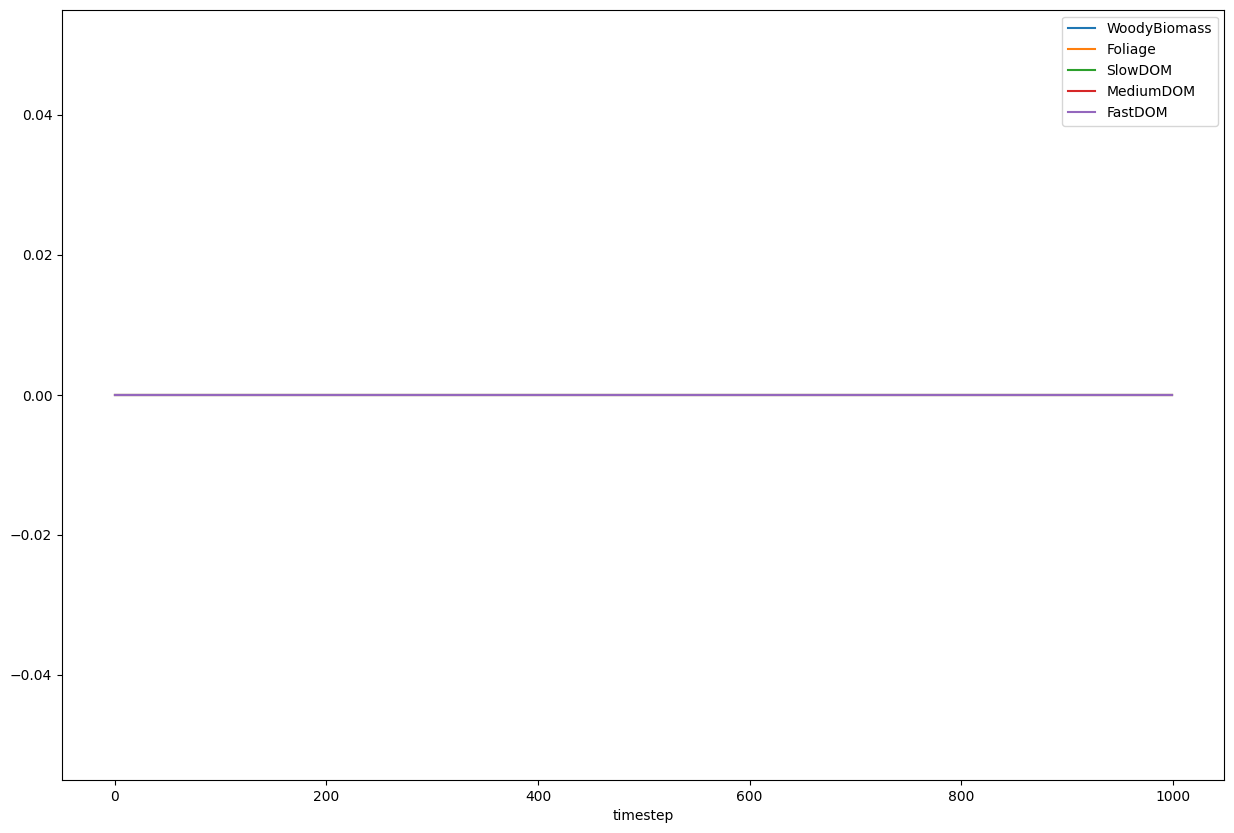

In [13]:
pools.to_pandas()[
    ['timestep','WoodyBiomass', 'Foliage', 'SlowDOM',
     'MediumDOM', 'FastDOM']
].groupby("timestep").sum().plot(figsize=(15,10))

<Axes: xlabel='timestep'>

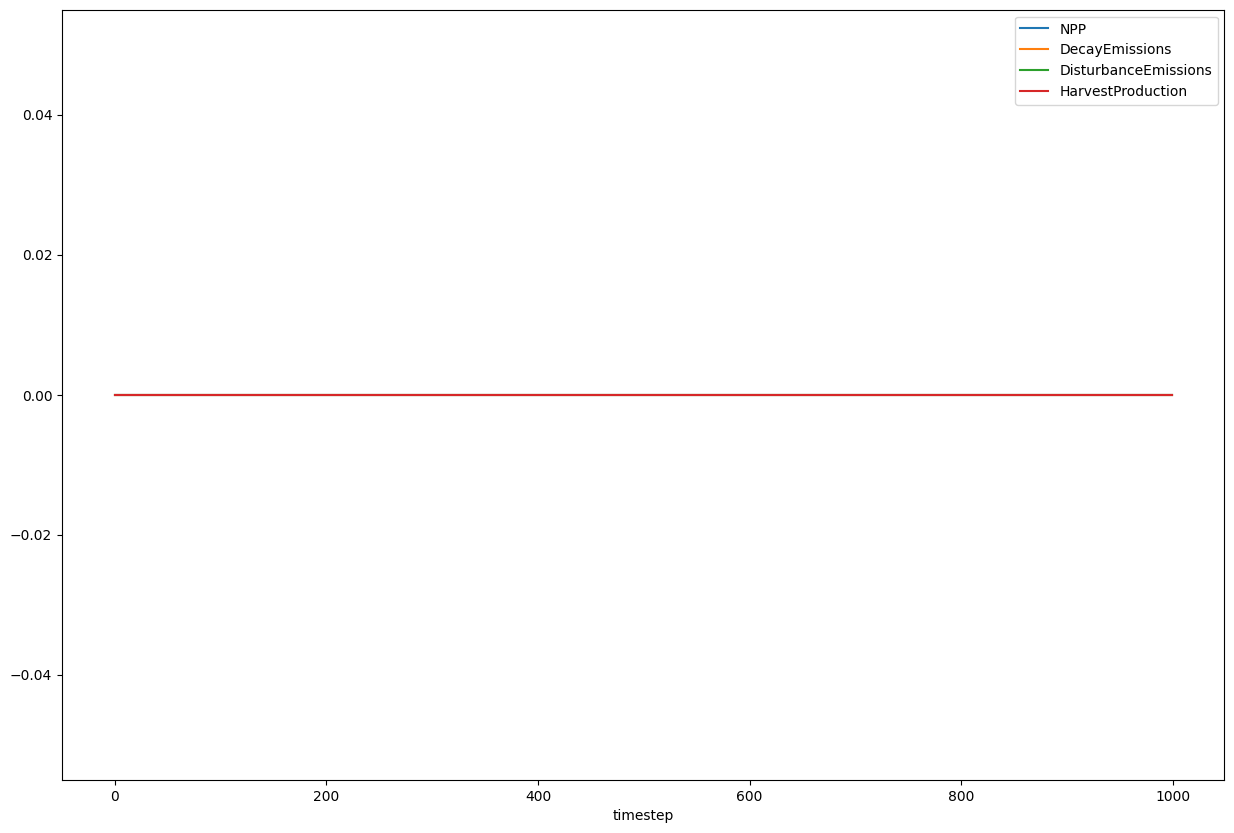

In [14]:
flux.to_pandas()[
    ['timestep', 'NPP', 'DecayEmissions', 'DisturbanceEmissions',
     'HarvestProduction']
].groupby("timestep").sum().plot(figsize=(15,10))